In [1]:
# ==========================================
# Vehicle Price Prediction using Linear Regression
# Part 1 : Data Loading & Exploratory Data Analysis
# Author : Mahika Bommana
# ==========================================

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option('display.max_columns', None)
pd.set_option('display.width',1000)

In [4]:
import zipfile

# Load Dataset
zip_file_path = '/content/cardekho_dataset.csv.zip'
csv_file_name = 'cardekho_dataset.csv'

# Extract the CSV file from the zip archive
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')

df = pd.read_csv(f'/content/{csv_file_name}')

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [5]:
print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print("\nShape :", df.shape)

print("\nColumns\n")
print(df.columns.tolist())

print("\nFirst Five Rows\n")
display(df.head())

DATASET OVERVIEW

Shape : (15411, 14)

Columns

['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

First Five Rows



,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [6]:
print("="*60)
print("DATASET INFORMATION")
print("="*60)

df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [7]:
print("="*60)
print("MISSING VALUES")
print("="*60)

missing = df.isnull().sum()

missing = missing[missing>0]

if len(missing)==0:
    print("No Missing Values Found.")
else:
    display(missing)

MISSING VALUES
No Missing Values Found.


In [9]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)
print("="*60)
print("STATISTICAL SUMMARY")
print("="*60)

display(df.describe())

Duplicate Rows : 0
STATISTICAL SUMMARY


,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [10]:
print(df.dtypes)

Unnamed: 0             int64
car_name              object
brand                 object
model                 object
vehicle_age            int64
km_driven              int64
seller_type           object
fuel_type             object
transmission_type     object
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
dtype: object


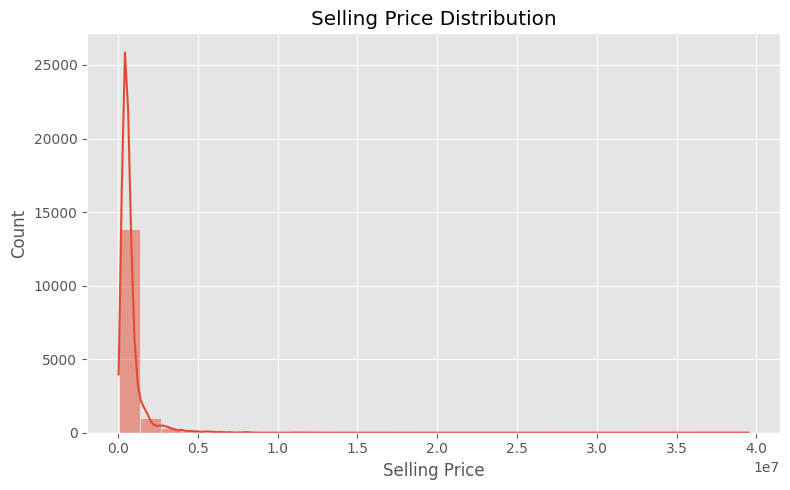

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df["selling_price"], bins=30, kde=True)

plt.title("Selling Price Distribution")
plt.xlabel("Selling Price")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

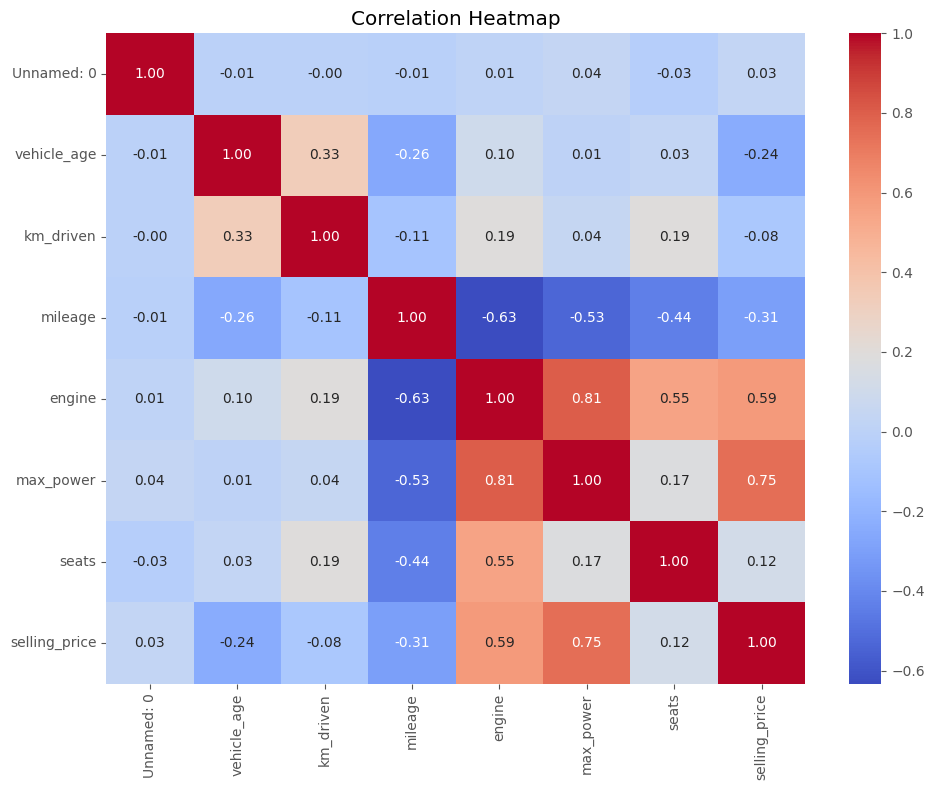

In [12]:
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include='number')

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

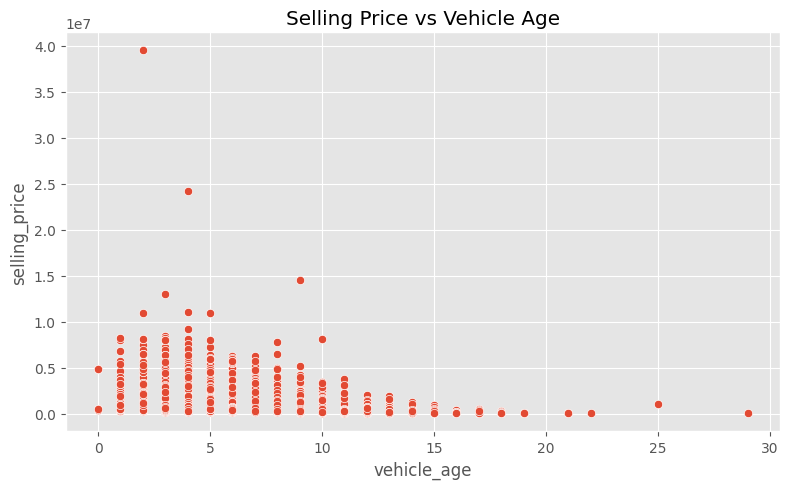

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="vehicle_age",
    y="selling_price",
    data=df
)

plt.title("Selling Price vs Vehicle Age")

plt.tight_layout()
plt.show()

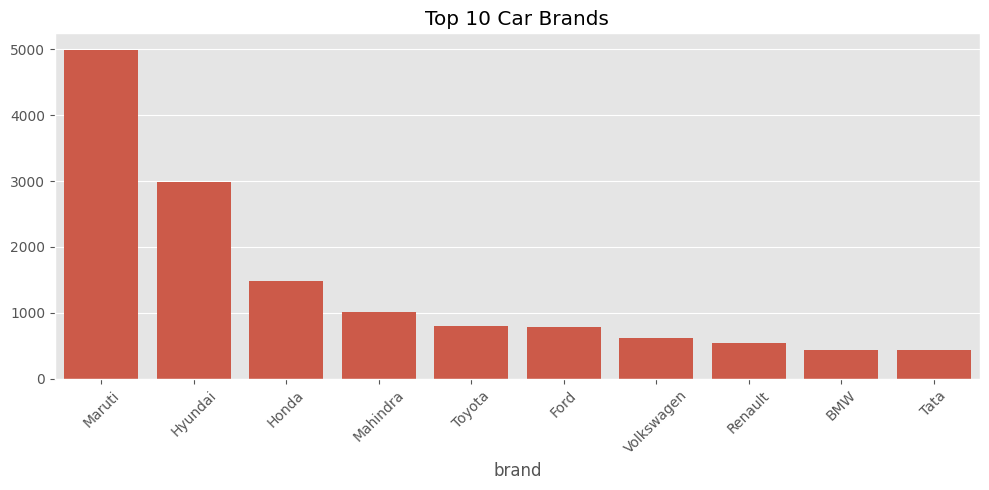

In [14]:
plt.figure(figsize=(10,5))

top_brands = df["brand"].value_counts().head(10)

sns.barplot(
    x=top_brands.index,
    y=top_brands.values
)

plt.xticks(rotation=45)

plt.title("Top 10 Car Brands")

plt.tight_layout()
plt.show()

## Key Insights

- The dataset contains over 15,000 used vehicle records.
- No missing values were found.
- Selling price is influenced by multiple numerical features such as engine size and vehicle age.
- The correlation heatmap provides an overview of relationships between numerical variables.
- The dataset is ready for preprocessing and model training.

Data Preprocessing & Model Training

In [15]:
# Drop unnecessary columns

df.drop(columns=["car_name"], inplace=True)

print("Updated Shape:", df.shape)

Updated Shape: (15411, 13)


In [16]:
X = df.drop("selling_price", axis=1)
y = df["selling_price"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

categorical_cols = X.select_dtypes(include="object").columns

numerical_cols = X.select_dtypes(exclude="object").columns

print("Categorical Features:")
print(categorical_cols)

print("\nNumerical Features:")
print(numerical_cols)

Features Shape: (15411, 12)
Target Shape: (15411,)
Categorical Features:
Index(['brand', 'model', 'seller_type', 'fuel_type', 'transmission_type'], dtype='object')

Numerical Features:
Index(['Unnamed: 0', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats'], dtype='object')


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 12328
Testing Samples  : 3083


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(
    X_train[numerical_cols]
)

X_test[numerical_cols] = scaler.transform(
    X_test[numerical_cols]
)
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Data Preprocessing & Model Training

In [21]:
X = df.drop("selling_price", axis=1)
y = df["selling_price"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (15411, 12)
Target Shape: (15411,)


In [22]:
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

print("Shape After Encoding:", X.shape)

Shape After Encoding: (15411, 164)


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 12328
Testing Samples  : 3083


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(
    X_train[numerical_cols]
)

X_test[numerical_cols] = scaler.transform(
    X_test[numerical_cols]
)

In [28]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully!")
predictions = model.predict(X_test)

print("First 10 Predictions:\n")

print(predictions[:10])

Model Trained Successfully!
First 10 Predictions:

[  68453.53401563  617513.10276151  622276.43720053 1224476.80999087
  -54645.38565029  436656.44580362  322099.2486277   251103.28260201
  356378.4068026  1837745.59498915]


In [29]:
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error

r2 = r2_score(y_test, predictions)

rmse = root_mean_squared_error(
    y_test,
    predictions
)

print("="*40)
print("MODEL PERFORMANCE")
print("="*40)

print(f"R² Score : {r2:.4f}")
print(f"RMSE     : {rmse:.2f}")

MODEL PERFORMANCE
R² Score : 0.8000
RMSE     : 387974.74


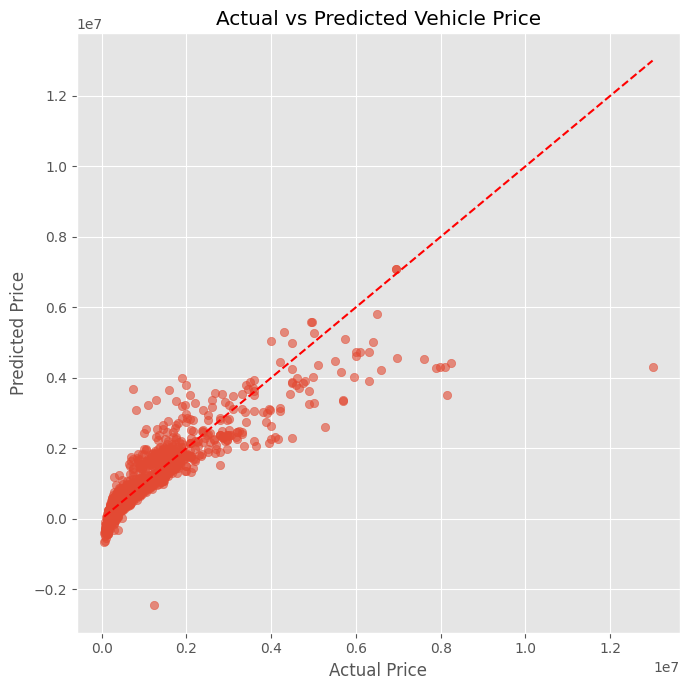

In [30]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    predictions,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Vehicle Price")

plt.tight_layout()

plt.show()

## Model Performance Summary

The Linear Regression model was successfully trained on the preprocessed vehicle dataset.

### Evaluation Metrics

- **R² Score** indicates how well the model explains the variance in vehicle prices.
- **RMSE (Root Mean Squared Error)** measures the average prediction error.

The Actual vs Predicted plot shows the relationship between the predicted prices and the actual selling prices. A closer alignment of the points to the diagonal line indicates better prediction performance.

# Conclusion

In this project, an end-to-end machine learning pipeline was developed to predict vehicle selling prices using Linear Regression.

### Steps Performed

- Loaded and explored the dataset
- Performed Exploratory Data Analysis (EDA)
- Encoded categorical features
- Scaled numerical features
- Split the data into training and testing sets
- Trained a Linear Regression model
- Evaluated the model using **R² Score** and **RMSE**
- Visualized prediction performance using an Actual vs Predicted plot

This project demonstrates the complete workflow of a regression-based machine learning model and provides a foundation for exploring more advanced regression algorithms in future work.

In [31]:
print("="*60)
print("Project Completed Successfully!")
print("="*60)

Project Completed Successfully!
